# ElasticNet Regression

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part A - Ridge , Lasso and ElasticNet Comparsion

### Import Sci-kit-learn Library Modules

In [39]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
     Ridge, Lasso, ElasticNet, ElasticNetCV
)
from sklearn.metrics import (
     mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.exceptions import ConvergenceWarning

### Load Datasets

In [40]:
dta=fetch_california_housing(as_frame=True)
x=dta.data
y=dta.target

print("Shape:",x.shape)
x.head()

Shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [41]:
X_train, X_test, y_train, y_test=train_test_split(
     x,y,
     test_size=0.25,random_state=42
)

### Evaluation Function

In [42]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    return {
        "model": name,
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "test_mae": mean_absolute_error(y_test, y_test_pred),
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "rmse_gap": test_rmse - train_rmse
    }

### Define Regularised Models

In [43]:
models={
     "Ridge":Pipeline([
          ("scaler",StandardScaler()),
          ("model",Ridge(alpha=1.0))
     ]),
     "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        ))
    ])   
}

### Train and Compare

In [44]:
results = []
fitted_models = {}

for name, model in models.items():
    result = evaluate_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append(result)
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="test_rmse")
results_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2,rmse_gap
1,Lasso,0.532967,0.532240,0.725295,0.731922,0.605751,0.595146,0.006627
2,ElasticNet,0.531311,0.530935,0.723732,0.732685,0.607448,0.594301,0.008953
0,Ridge,0.529511,0.529691,0.721493,0.735593,0.609873,0.591075,0.014100


### Compare Coefficients

In [45]:
coef_df=pd.DataFrame({
     "feature": x.columns,
    "Ridge": fitted_models["Ridge"].named_steps["model"].coef_,
    "Lasso": fitted_models["Lasso"].named_steps["model"].coef_,
    "ElasticNet": fitted_models["ElasticNet"].named_steps["model"].coef_,
})
print(coef_df)

print("\nZero coefficient count:")
for model_name in ["Ridge", "Lasso", "ElasticNet"]:
    zero_count = np.sum(np.isclose(coef_df[model_name], 0))
    print(f"{model_name}: {zero_count}")

      feature     Ridge     Lasso  ElasticNet
0      MedInc  0.852043  0.797940    0.821016
1    HouseAge  0.120738  0.125013    0.127903
2    AveRooms -0.301876 -0.166669   -0.221033
3   AveBedrms  0.348323  0.211900    0.263052
4  Population -0.001617 -0.000000    0.000000
5    AveOccup -0.041168 -0.030794   -0.036172
6    Latitude -0.892347 -0.788125   -0.786344
7   Longitude -0.867029 -0.755196   -0.756509

Zero coefficient count:
Ridge: 0
Lasso: 1
ElasticNet: 1


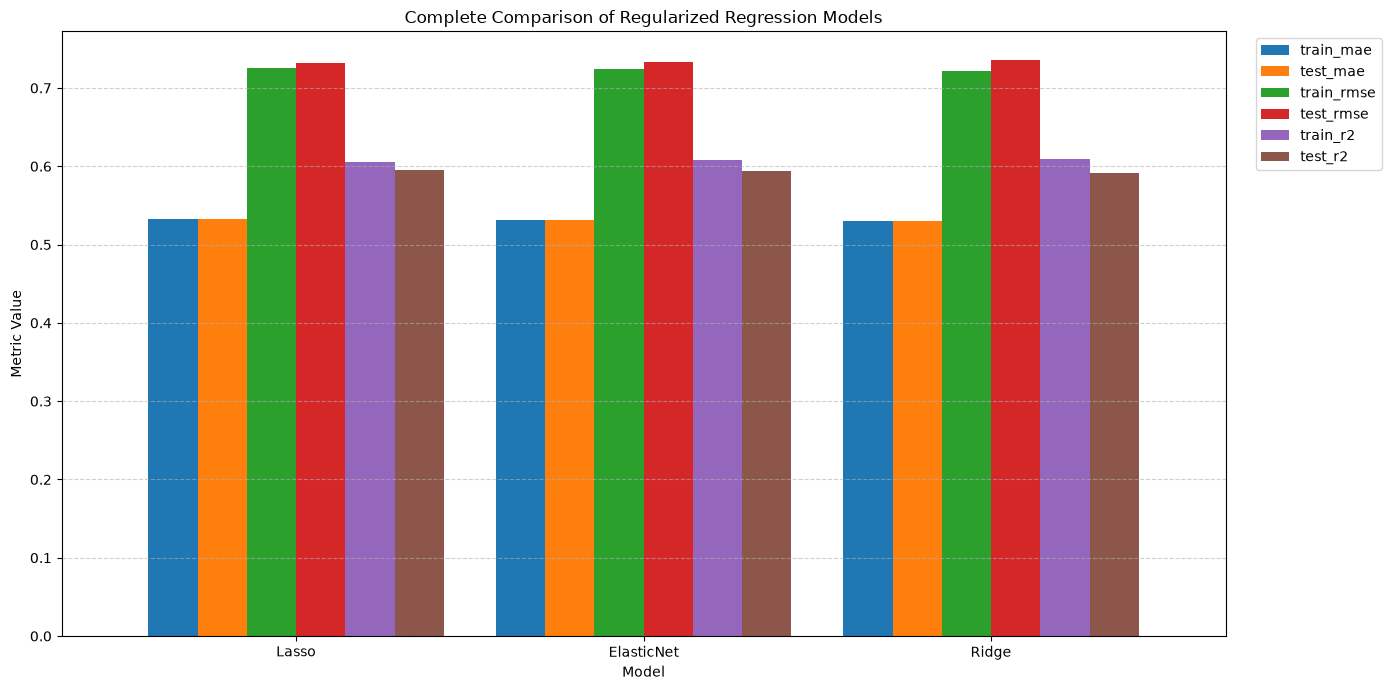

In [46]:
metrics = [
    "train_mae", "test_mae",
    "train_rmse", "test_rmse",
    "train_r2", "test_r2"
]

plot_df = results_df.set_index("model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.85
)

plt.title("Complete Comparison of Regularized Regression Models")
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

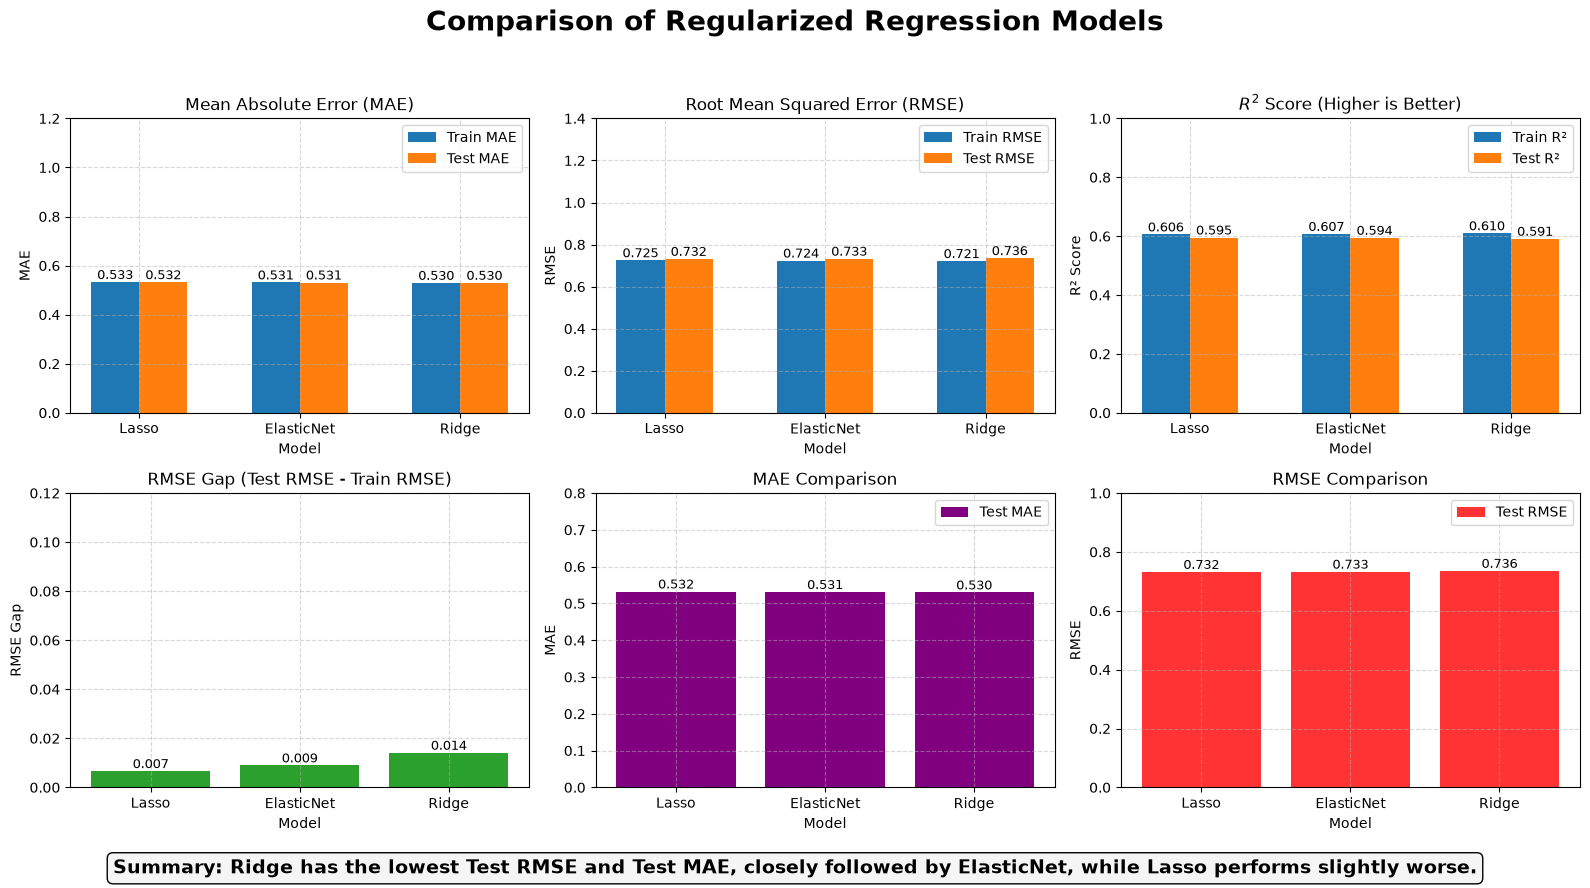

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    "Comparison of Regularized Regression Models",
    fontsize=20,
    fontweight="bold"
)

models = results_df["model"]
x = np.arange(len(models))
width = 0.30

# ================= MAE =================
ax = axes[0, 0]
b1 = ax.bar(x - width/2,
            results_df["train_mae"],
            width,
            color="tab:blue",
            label="Train MAE")

b2 = ax.bar(x + width/2,
            results_df["test_mae"],
            width,
            color="tab:orange",
            label="Test MAE")

ax.set_title("Mean Absolute Error (MAE)")
ax.set_ylabel("MAE")
ax.set_xlabel("Model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.2)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()


# ================= RMSE =================
ax = axes[0, 1]
b1 = ax.bar(x - width/2,
            results_df["train_rmse"],
            width,
            color="tab:blue",
            label="Train RMSE")

b2 = ax.bar(x + width/2,
            results_df["test_rmse"],
            width,
            color="tab:orange",
            label="Test RMSE")

ax.set_title("Root Mean Squared Error (RMSE)")
ax.set_ylabel("RMSE")
ax.set_xlabel("Model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.4)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()


# ================= R2 =================
ax = axes[0, 2]
b1 = ax.bar(x - width/2,
            results_df["train_r2"],
            width,
            color="tab:blue",
            label="Train R²")

b2 = ax.bar(x + width/2,
            results_df["test_r2"],
            width,
            color="tab:orange",
            label="Test R²")

ax.set_title(r"$R^2$ Score (Higher is Better)")
ax.set_ylabel("R² Score")
ax.set_xlabel("Model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()


# ================= RMSE GAP =================
ax = axes[1, 0]
bars = ax.bar(models,
              results_df["rmse_gap"],
              color="tab:green")

ax.set_title("RMSE Gap (Test RMSE - Train RMSE)")
ax.set_ylabel("RMSE Gap")
ax.set_xlabel("Model")
ax.set_ylim(0, 0.12)
ax.grid(True, linestyle="--", alpha=0.5)


# ================= MAE COMPARISON =================
ax = axes[1, 1]
bars = ax.bar(models,
              results_df["test_mae"],
              color="purple",
              label="Test MAE")

ax.set_title("MAE Comparison")
ax.set_ylabel("MAE")
ax.set_xlabel("Model")
ax.set_ylim(0, 0.8)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()


# ================= RMSE COMPARISON =================
ax = axes[1, 2]
bars = ax.bar(models,
              results_df["test_rmse"],
              color="red",
              alpha=0.8,
              label="Test RMSE")

ax.set_title("RMSE Comparison")
ax.set_ylabel("RMSE")
ax.set_xlabel("Model")
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()


# ============== VALUE LABELS ==============
for ax in axes.flat:
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            (bar.get_x() + bar.get_width()/2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

# Summary box
fig.text(
    0.5,
    0.02,
    "Summary: Ridge has the lowest Test RMSE and Test MAE, closely followed by ElasticNet, while Lasso performs slightly worse.",
    ha="center",
    fontsize=14,
    weight="bold",
    bbox=dict(boxstyle="round", facecolor="whitesmoke")
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Plot Coeffieicents

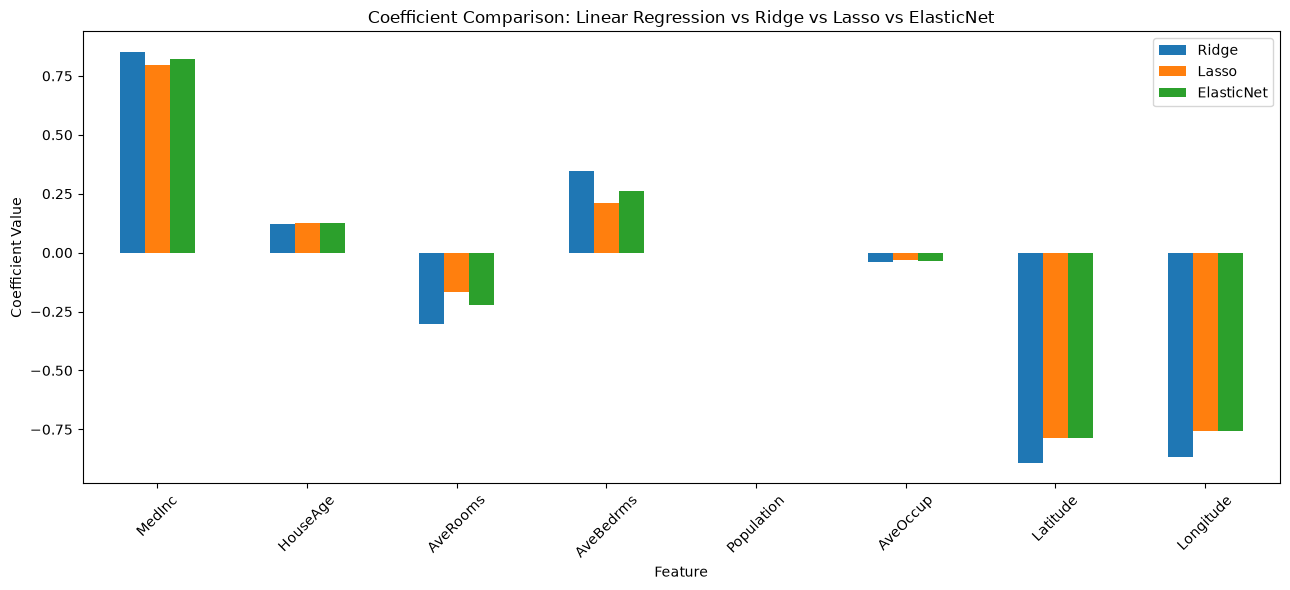

In [48]:
coef_plot_df = coef_df.set_index("feature")

coef_plot_df.plot(kind="bar", figsize=(13, 6))

plt.title("Coefficient Comparison: Linear Regression vs Ridge vs Lasso vs ElasticNet")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plot Shrinkage

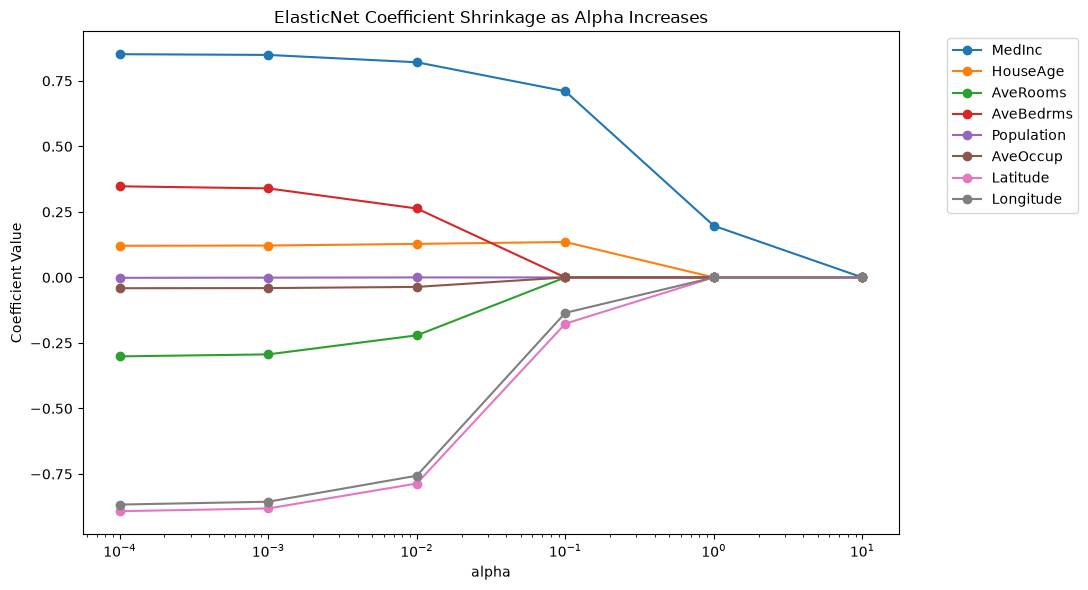

In [50]:
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]
coefs = []
for alpha in alpha_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("elasticnet", ElasticNet(
            alpha=alpha,l1_ratio=0.5,
            max_iter=30000,random_state=42
        ))
    ])
    model.fit(X_train, y_train)
    coefs.append(model.named_steps["elasticnet"].coef_)
coefs = np.array(coefs)
plt.figure(figsize=(11, 6))
for feature_index, feature_name in enumerate(dta.feature_names):
    plt.plot(
        alpha_values,coefs[:, feature_index],
        marker="o",label=feature_name
    )
plt.xscale("log")
plt.title("ElasticNet Coefficient Shrinkage as Alpha Increases")
plt.xlabel("alpha")
plt.ylabel("Coefficient Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Train ElasticNetCV

In [ ]:
elastic_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnetcv", ElasticNetCV(
        alphas=[0.001, 0.01, 0.1, 1, 10],
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=30000,
        random_state=42
    ))
])

elastic_cv_pipeline.fit(X_train, y_train)

best_elastic = elastic_cv_pipeline.named_steps["elasticnetcv"]

print("Best alpha:", best_elastic.alpha_)
print("Best l1_ratio:", best_elastic.l1_ratio_)

Best alpha: 0.001
Best l1_ratio: 0.9


### Evalute ElasticNetCV

In [ ]:
y_train_pred=elastic_cv_pipeline.predict(X_train)
y_test_pred=elastic_cv_pipeline.predict(X_test)

elastic_cv_result = {
    "model": "ElasticNetCV",
    "train_MAE": mean_absolute_error(y_train, y_train_pred),
    "test_MAE": mean_absolute_error(y_test, y_test_pred),
    "train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    "test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    "train_R2": r2_score(y_train, y_train_pred),
    "test_R2": r2_score(y_test, y_test_pred),
}

elastic_cv_result["RMSE_gap"] = (
    elastic_cv_result["test_RMSE"] - elastic_cv_result["train_RMSE"]
)

display(pd.DataFrame([elastic_cv_result]))

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,RMSE_gap
0,ElasticNetCV,0.529573,0.529688,0.721529,0.734882,0.609834,0.591865,0.013353


### Add ElasticNetCV to Final Comparison

In [ ]:
final_results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([elastic_cv_result])
    ],
    ignore_index=True
)

final_results_df = final_results_df.sort_values(by="test_RMSE")

display(final_results_df)

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2,rmse_gap,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,RMSE_gap
3,ElasticNetCV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.529573,0.529688,0.721529,0.734882,0.609834,0.591865,0.013353
0,Lasso,0.532967,0.532240,0.725295,0.731922,0.605751,0.595146,0.006627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ElasticNet,0.531311,0.530935,0.723732,0.732685,0.607448,0.594301,0.008953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ridge,0.529511,0.529691,0.721493,0.735593,0.609873,0.591075,0.014100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### ElasticNetCV Coefficients

In [ ]:
elastic_cv_coef_df = pd.DataFrame({
    "feature": dta.feature_names,"coefficient": best_elastic.coef_
})
elastic_cv_coef_df["abs_coefficient"] = elastic_cv_coef_df["coefficient"].abs()
elastic_cv_coef_df = elastic_cv_coef_df.sort_values(
    by="abs_coefficient",ascending=False
)
display(elastic_cv_coef_df)
zero_count = np.sum(np.isclose(best_elastic.coef_, 0))
non_zero_count = len(best_elastic.coef_) - zero_count
print("Zero coefficients    :", zero_count)
print("Non-zero coefficients:", non_zero_count)

,feature,coefficient,abs_coefficient
6,Latitude,-0.882066,0.882066
7,Longitude,-0.856144,0.856144
0,MedInc,0.847233,0.847233
3,AveBedrms,0.335972,0.335972
2,AveRooms,-0.289605,0.289605
1,HouseAge,0.121505,0.121505
5,AveOccup,-0.040318,0.040318
4,Population,-0.000479,0.000479


Zero coefficients    : 0
Non-zero coefficients: 8


### plot ElasticNetCv Coefficients

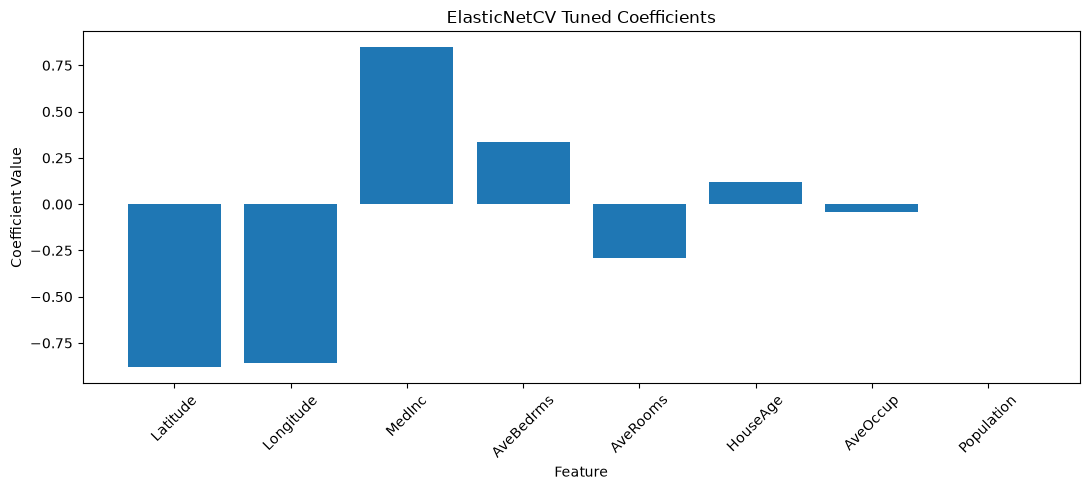

In [52]:
plt.figure(figsize=(11, 5))

plt.bar(
    elastic_cv_coef_df["feature"],
    elastic_cv_coef_df["coefficient"]
)

plt.title("ElasticNetCV Tuned Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Broken Model to Trigger Warning

In [ ]:
import warnings
bad_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNet(
        alpha=0.000001,
        l1_ratio=0.9,
        max_iter=5,
        tol=1e-8,
        random_state=42
    ))
])
with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    bad_model.fit(X_train, y_train)

    for warning in caught_warnings:
        print(type(warning.message).__name__)
        print(warning.message)

ConvergenceWarning
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.258841e+03, tolerance: 2.066e-04


### Fixed Version

In [56]:
fixed_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=30000,
        tol=1e-4,
        random_state=42
    ))
])
fixed_model.fit(X_train, y_train)
y_pred = fixed_model.predict(X_test)
print("Fixed ElasticNet Performance")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

Fixed ElasticNet Performance
MAE : 0.5309354193315315
RMSE: 0.7326854534350667
R2  : 0.5943012178550884
